<a href="https://colab.research.google.com/github/Rishi5105-kashyap/Codtech-tasks/blob/main/codtech_task_4_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Codtech task 4 submission


===== MOVIELENS DATASET (first 5 rows) ====
   User  Movie  Rating  timestamp
0     1      1     4.0  964982703
1     1      3     4.0  964981247
2     1      6     4.0  964982224
3     1     47     5.0  964983815
4     1     50     5.0  964982931

===== USER-MOVIE MATRIX (first 5x5 rows) ====
Movie    1    2    3    4    5
User                          
1      4.0  0.0  4.0  0.0  0.0
2      0.0  0.0  0.0  0.0  0.0
3      0.0  0.0  0.0  0.0  0.0
4      0.0  0.0  0.0  0.0  0.0
5      4.0  0.0  0.0  0.0  0.0

===== USER SIMILARITY MATRIX (first 5x5 rows) ====
User         1         2         3         4         5
User                                                  
1     1.000000  0.027283  0.059720  0.194395  0.129080
2     0.027283  1.000000  0.000000  0.003726  0.016614
3     0.059720  0.000000  1.000000  0.002251  0.005020
4     0.194395  0.003726  0.002251  1.000000  0.128659
5     0.129080  0.016614  0.005020  0.128659  1.000000

===== MODEL TRAINED SUCCESSFULLY ====

Testing re

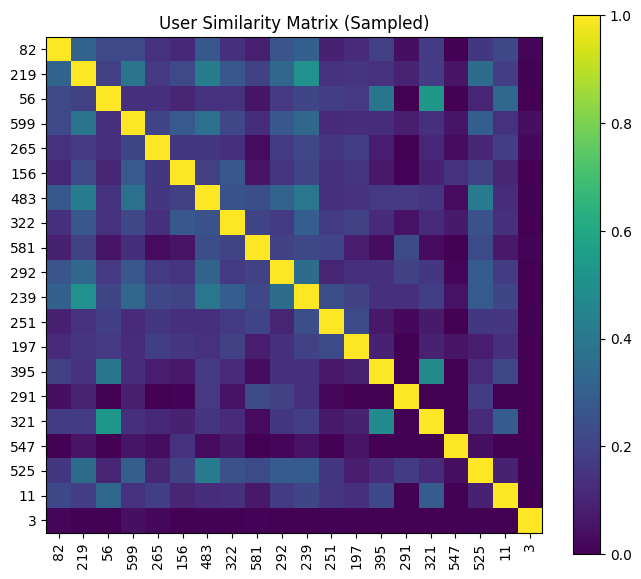


===== EVALUATION ====
Average User Similarity Score: 0.1

===== NEW USER EXAMPLE (Conceptual) ====
To integrate a new user, their ratings would need to be added 
to the dataset, and the user-item matrix and KNN model would need to be updated.
For example, a new user might rate Movie 296 (Pulp Fiction) as 5, Movie 356 (Forrest Gump) as 4.

===== RECOMMENDATION SYSTEM PROJECT COMPLETED (MovieLens Data) ====


In [4]:
# ============================================================
# RECOMMENDATION SYSTEM PROJECT
# COLLABORATIVE FILTERING USING KNN
# ============================================================

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import requests
import zipfile
import io

# ============================================================
# STEP 2: LOAD MOVIELENS DATASET
# ============================================================

zip_url = 'http://files.grouplens.org/datasets/movielens/ml-latest-small.zip'

print(f"Downloading MovieLens dataset from: {zip_url}")
response = requests.get(zip_url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

zip_file = zipfile.ZipFile(io.BytesIO(response.content))

with zip_file.open('ml-latest-small/ratings.csv') as f:
    df = pd.read_csv(f)

df = df.rename(columns={'userId': 'User', 'movieId': 'Movie', 'rating': 'Rating'})

print("\n===== MOVIELENS DATASET (first 5 rows) ====")
print(df.head())

# ============================================================
# STEP 3: CREATE USER-ITEM MATRIX
# ============================================================

user_movie_matrix = df.pivot_table(
    index='User',
    columns='Movie',
    values='Rating'
).fillna(0)

print("\n===== USER-MOVIE MATRIX (first 5x5 rows) ====")
print(user_movie_matrix.iloc[:5, :5])

# ============================================================
# STEP 4: CALCULATE COSINE SIMILARITY
# ============================================================

similarity = cosine_similarity(user_movie_matrix)

similarity_df = pd.DataFrame(
    similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

print("\n===== USER SIMILARITY MATRIX (first 5x5 rows) ====")
print(similarity_df.iloc[:5, :5])

# ============================================================
# STEP 5: TRAIN KNN MODEL
# ============================================================

model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

model.fit(user_movie_matrix)

print("\n===== MODEL TRAINED SUCCESSFULLY ====")

# ============================================================
# STEP 6: RECOMMEND MOVIES FUNCTION
# ============================================================

def recommend_movies(user_name, n_recommendations=5):

    print(f"\n===== RECOMMENDATIONS FOR {user_name} ====")

    if user_name not in user_movie_matrix.index:
        print(f"User {user_name} not found in the dataset.")
        return

    user_index = user_movie_matrix.index.tolist().index(user_name)

    num_users = len(user_movie_matrix.index)
    k_neighbors = min(num_users, 3)
    if k_neighbors < 2:
        print("Not enough users to find similar neighbors.")
        return

    distances, indices = model.kneighbors(
        user_movie_matrix.iloc[user_index, :].values.reshape(1, -1),
        n_neighbors=k_neighbors + 1
    )

    similar_users_indices = indices.flatten()[1:]
    similar_users = user_movie_matrix.index[similar_users_indices].tolist()

    print("\nSimilar Users:")
    print(similar_users)

    user_movies = set(
        df[df['User'] == user_name]['Movie']
    )

    recommendations = []

    for sim_user in similar_users:

        sim_user_movies_ratings = df[df['User'] == sim_user]

        for index, row in sim_user_movies_ratings.iterrows():
            movie = row['Movie']
            rating = row['Rating']
            if movie not in user_movies and rating >= 4:
                recommendations.append(movie)

    recommendations = list(set(recommendations))

    if recommendations:
        print("\nRecommended Movies (Movie IDs):")
        for movie_id in recommendations[:n_recommendations]:
            print(movie_id)
    else:
        print("No new recommendations found for this user.")

# ============================================================
# STEP 7: TEST RECOMMENDATION SYSTEM
# ============================================================

example_user = df['User'].sample(1).iloc[0]
print(f"\nTesting recommendations for a random user: {example_user}")
recommend_movies(example_user, n_recommendations=5)

# ============================================================
# STEP 8: VISUALIZE SIMILARITY MATRIX
# ============================================================

# For larger datasets, visualizing the full similarity matrix is impractical.
# Sampled for visualization purposes.
if similarity_df.shape[0] > 20:
    sample_users = similarity_df.index.to_series().sample(min(20, similarity_df.shape[0]), random_state=42)
    sampled_similarity_df = similarity_df.loc[sample_users, sample_users]
    sampled_similarity = sampled_similarity_df.values
    sampled_indices = sampled_similarity_df.index
else:
    sampled_similarity_df = similarity_df
    sampled_similarity = similarity
    sampled_indices = user_movie_matrix.index

plt.figure(figsize=(8, 7))

plt.imshow(sampled_similarity, cmap='viridis')

plt.title("User Similarity Matrix (Sampled)")

plt.colorbar()

plt.xticks(
    range(len(sampled_indices)),
    sampled_indices,
    rotation=90
)

plt.yticks(
    range(len(sampled_indices)),
    sampled_indices
)

plt.show()

# ============================================================
# STEP 9: SIMPLE EVALUATION METRIC
# ============================================================

avg_similarity = np.mean(similarity)

print("\n===== EVALUATION ====")

print("Average User Similarity Score:",
      round(avg_similarity, 2))

# ============================================================
# STEP 10: ADD NEW USER EXAMPLE (Conceptual for MovieLens)
# ============================================================

print("\n===== NEW USER EXAMPLE (Conceptual) ====")
print("To integrate a new user, their ratings would need to be added ")
print("to the dataset, and the user-item matrix and KNN model would need to be updated.")
print("For example, a new user might rate Movie 296 (Pulp Fiction) as 5, Movie 356 (Forrest Gump) as 4.")

# ============================================================
# END OF PROJECT
# ============================================================

print("\n===== RECOMMENDATION SYSTEM PROJECT COMPLETED (MovieLens Data) ====")